# Stochastic subgradient descent

## Part 1: Algorithm implementation

Here we try to define the problem:

Given a RV si follow a distribution with probability P over Si, find the minimal x* in X for the Expectation of function f: X x Si -> R

### Function Definition

Here we first define the mapping of RV si to a L-lipschitz convex function f(x)

1. We assume that the L-lipschitz convex function is the maximum of a set of affine functinos ax + b
2. As in the assumption, we need the slope of affine have absolute value smaller than L (|a| < L)
3. The function should have a constant mapping of random variable si to all parameters including count, slope and intersection of affine functions.


For the subgradient
- Check if x lands in intersection by finding the maximum value of all affine evaluates
- If so, take any gradient within the range of intersecting affine, which is achieved by the affine combination of the slopes

In [ ]:
from typing import List
import numpy as np

MAX_AFFINE = 20


class Realization:
    """Realization of f given fixed rv"""
    def __init__(self, d: int, L: float, si: np.ndarray):
        # self.M = M
        self.d = d
        self.L = L
        self.si = si # Random variable input
        
        self._cov = self._xi_to_cov(si) # Cov of weights
        self._bias_var = min(np.linalg.norm(si), 1)
        self.M = self._xi_to_M(si) # count of affine
        
        # set function weights 
        rand_weights = np.random.multivariate_normal(np.zeros(shape=(d,)), self._cov, size=(self.M,))
        # Normalize rows for L lipschitz
        for row in rand_weights:
            norm = np.linalg.norm(row)
            if  norm > L:
                row = (row / norm) * L
        self._weights = rand_weights
        
        self._bias = np.random.normal(0, self._bias_var, size=(self.M,))
        
    def _xi_to_cov(self, si: np.ndarray):
        # si is in Rq
        assert len(si.shape) == 1
        q = si.shape[0]
        d = self.d
        
        # Compose a Cov PD matrix uxing a fixed mapping
        projection_matrix = np.cos(np.outer(np.arange(d), np.arange(q)))
        # print("projection_matrix: ", projection_matrix)
        A = (projection_matrix @ si)
        sigma = A @ A.T
        
        # Add small trace
        return sigma + np.eye(d) * 1e-5
        
        
    def _xi_to_M(self, si: np.ndarray):
        """Map si to 1D M in [1, 50] int"""
        scalar = np.linalg.norm(si)
        normalized_val = (2 / np.pi) * np.arctan(scalar)
        
        # Scale back to 1, 50
        return int(np.floor(normalized_val * (MAX_AFFINE - 1)) + 1)
        
        
       
    def __call__(self, x: np.ndarray):
        """evaluate f(x)"""
        assert x.shape[0] == self.d, print(f"Invalid dimension: {x.shape}, d: {self.d}")
        values = (self._weights @ x) + self._bias
        return np.max(values)
    
    def subgrad(self, x: np.ndarray):
        assert x.shape[0] == self.d, print(f"Invalid dimension: {x.shape}, d: {self.d}")
        
        values = (self._weights @ x) + self._bias
        max_val = max(values)
        # tolerance matching
        is_active = np.isclose(values, max_val, atol=1e-9)
        active_weights = self._weights[is_active]
        active_count = len(active_weights)
        
        # If only one affine is active, return that as grad
        if active_count == 1:
            return active_weights[0]
        
        # In case of more than one active count
        # get some affine combination of all grad
        # Shape: k,d.T @ k, => d,
        lambdas = np.random.dirichlet([1.0] * active_count)
        return active_weights.T @ lambdas
    



### Testing of realization

Here we check the behaviour of our generating function

1. Generate suitable si
2. Run the realization 
3. Plot all affine 
4. Since the realization is implemeented with a call, we just call the function with the realization and plot the function evaluate using the red line
5. In a constant linespace, we also plot their respective subgradient. Most likely the intersection is not exactly on the line space, but there are some small chance that there are some blue line that is not the gray affine, thats the random subgradient

si:  [0.21774188 0.11045291 0.08749103 0.43046318 0.06405919]
weights:  [[ 1.56486373]
 [ 2.05763954]
 [-0.19693509]
 [ 1.89390954]
 [ 1.54317705]
 [ 1.88166767]]
bias:  [-0.68000889 -0.17561729  0.24901594 -0.49658062 -0.09199133  0.03733358]
M (affine count):  6


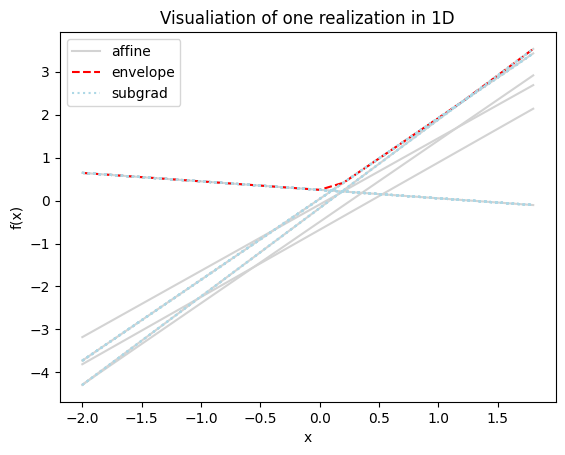

In [611]:
import matplotlib.pyplot as plt

## As a sample, we show graph with d=1
L = 5
q = 5
si = np.random.random(size=(q,))
realization1 = Realization(1, L, si)

# Show numerical values
print("si: ", si)
print("weights: ", realization1._weights)
print("bias: ", realization1._bias)
print("M (affine count): ", realization1.M)

# Plot the affine functions
weights = realization1._weights
bias = realization1._bias
x = np.arange(-2, 2, 0.2)
for i, (a, b) in enumerate(zip(weights, bias)):
    y = [a*x_i + b for x_i in x]
    label = "affine" if i == 0 else ""
    plt.plot(x, y, color="lightgrey", label=label)
    

# Plot the convex envelop
fx = [realization1(np.array([x_i])) for x_i in x]
plt.plot(x, fx, color="red", linestyle="--", label="envelope")

# Test subgradient
# NOTE: It is quite rare for the point to directly coincide with intersections 
# (where gradient become subgradient)
# We can randomize more attempts to get the extra line
for i, x_i in enumerate(x):
    x_pt = np.array([x_i])
    f_x = realization1(x_pt)
    subgrad = realization1.subgrad(x_pt)
    y_support = subgrad * (x - x_i) + f_x
    label = "subgrad" if i == 0 else ""
    plt.plot(x, y_support, color='lightblue', linestyle="dotted", label=label)
    
 
# Styling
plt.title("Visualiation of one realization in 1D")
plt.ylabel("f(x)")
plt.xlabel("x")
plt.legend()

### Main training loop

In [612]:
from dataclasses import dataclass
from typing import Callable

def lr(t: int) -> float:
    return 1 / np.sqrt(t + 1)
    # return 1
    

@dataclass
class SsgdResult:
    grad_hist: List[np.ndarray]
    x_hist: List[np.ndarray]
    x_mean_hist: List[np.ndarray]
    
def ssgd(d: int, T: int, L: float, lr: Callable[[int], float], si: np.ndarray):
    """given a predecided si (T, d), run ssgd to find minizer of expected f"""
    x = np.random.rand(d)
    
    grad_hist = []
    x_hist = []
    
    lr_agg = 0
    lr_x_agg = 0
    x_mean_hist = []
        
    for t in range(T):
        # Use given si to create realization object
        realization = Realization(d, L, si[t])
        
        # Compute subgradient at current x
        g = realization.subgrad(x)
        
        # Store for monitoring
        grad_hist.append(g)
        
        # Update step
        x = x - lr(t) * g
        x_hist.append(x)

        # Track x_mean
        lr_agg += lr(t)
        lr_x_agg += lr(t) * x
        
        x_mean = lr_x_agg / lr_agg
        x_mean_hist.append(x_mean)
        
        
        
    return SsgdResult(
        grad_hist=grad_hist,
        x_hist=x_hist,
        x_mean_hist=x_mean_hist
    )
        
    


### Show convergence

Here we want to find the convergence of x_mean in expected value of f(x_mean) over random variable si

Since we dont have the close form for f(si), we use out sample to simulate the expected value

1. Run ssgd to get the x_mean history
2. Generate a new set of function from the same distribution
3. Evaluate the values of x_mean against out_sample functions

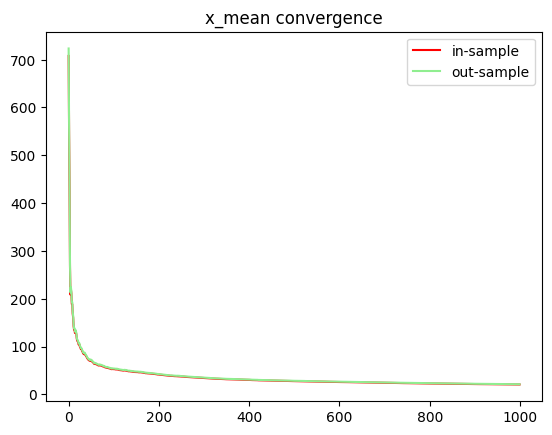

In [613]:
in_sample_count = 1000
out_sample_count = 500
d = 10
L = 5.0

si = np.random.random(size=(in_sample_count, d))
result = ssgd(d, in_sample_count, L, lr, si)
# This is the main variable that shows convergence
x_mean_hist = result.x_mean_hist

# We split into 2 case, in-sample and out-sample
# First we find average value of insample
x_mean_in = [] 
for i in range(in_sample_count):
    # Reconstruct the realizations as in ssgd
    realization = Realization(d, L, si[i])
    vals = [realization(x_mean_i) for  x_mean_i in x_mean_hist]
    x_mean_in.append(vals)


si2 = np.random.random(size=(out_sample_count, d))
x_mean_eval = [] 
for i in range(out_sample_count):
    realization = Realization(d, L, si2[i])
    vals = [realization(x_mean_i) for  x_mean_i in x_mean_hist]
    x_mean_eval.append(vals)
    
# We find the mean of each step
avg_x_in = np.array(x_mean_in).mean(axis=0)
avg_x_eval = np.array(x_mean_eval).mean(axis=0)

# Plot graph
plt.title("x_mean convergence")
plt.plot(avg_x_in, color="red", label="in-sample")
plt.plot(avg_x_eval, color="lightgreen", label="out-sample")
plt.legend()

    




## Conclusion

In the graph we can see the convergence of Expected value in terms of x_mean, which is in O(1/sqrt(t))

This behaviour is generalizable for the same distribution of function in terms of si.